# Auto-size & optimize: three production-optimization workflows

This notebook shows how to drive NeqSim's **production optimizer** with a minimum of Python.
The heavy lifting (auto-sizing equipment, building capacity constraints, the throughput search)
is done entirely inside Java NeqSim — Python only *builds the plant* and *reads results*.

It is a companion to the
[Production Optimization Guide](https://equinor.github.io/neqsim/examples/PRODUCTION_OPTIMIZATION_GUIDE.html).

| Scenario | What is given | Workflow |
|----------|---------------|----------|
| **A** | *Nothing* — only stream conditions | `autoSizeEquipment()` → optimize |
| **B** | A larger preliminary train design basis | size the equipment to the design duty → optimize |
| **C** | Nothing first, then a larger design basis | auto-size → optimize → update with revised design sizes → re-optimize |

All three reuse the **same** tiny `size_for()` + `maximize_throughput()` helpers, so changing
the installed equipment is just changing one number — the throughput the plant is sized for.

The generated charts and dimensions are preliminary educational sizing. A real
installed machine requires its vendor map, operating limits and driver rating.
All throughput claims are bounded by the specified search interval.


**Runtime:** Use Git and JDK 17 or newer. The setup uses compiled repository classes when present; otherwise it fetches and builds the corrected documentation source from `refs/pull/3597/head`. Set `NEQSIM_GIT_REF` to validate another fixed revision. The public Python package alone does not contain all Java fixes exercised here. Run all cells from a fresh kernel.


In [1]:
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

# Install Python packages with this notebook kernel. Java runs from the
# validated documentation source below, ahead of the package's bundled JAR.
required = {"neqsim": "neqsim>=3.20.0,<4", "numpy": "numpy",
            "scipy": "scipy>=1.14,<2", "matplotlib": "matplotlib", "pandas": "pandas"}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

candidate = Path(os.environ.get("NEQSIM_PROJECT_ROOT", Path.cwd())).resolve()
PROJECT_ROOT = next((p for p in [candidate, *candidate.parents]
                     if (p / "pom.xml").is_file()
                     and (p / "devtools/neqsim_dev_setup.py").is_file()), None)
if PROJECT_ROOT is None:
    # The public package alone predates fixes exercised by these examples.
    # Use the validated documentation PR's source; override with another fixed
    # commit or ref through NEQSIM_GIT_REF when validating a newer revision.
    source_ref = os.environ.get("NEQSIM_GIT_REF", "refs/pull/3597/head")
    PROJECT_ROOT = Path(tempfile.mkdtemp(prefix="neqsim-optimization-"))
    subprocess.check_call(["git", "init", "-q", str(PROJECT_ROOT)])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "remote", "add", "origin",
                           "https://github.com/equinor/neqsim.git"])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "fetch", "--depth", "1",
                           "origin", source_ref])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "checkout", "--quiet",
                           "--detach", "FETCH_HEAD"])
    print(f"Fetched NeqSim documentation source: {source_ref}")

if not (PROJECT_ROOT / "target/classes/neqsim/thermo/system/SystemSrkEos.class").is_file():
    # Requires Git and JDK 17+ before the first source build.
    # The Maven wrapper downloads its own Maven distribution and dependencies.
    wrapper = "mvnw.cmd" if os.name == "nt" else "mvnw"
    build = subprocess.run(
        [str(PROJECT_ROOT / wrapper), "-q", "-DskipTests", "compile",
         "dependency:build-classpath", "-DincludeScope=runtime",
         "-Dmdep.outputFile=target/neqsim-dev-classpath.txt",
         f"-Dmdep.pathSeparator={os.pathsep}"],
        cwd=PROJECT_ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    if build.returncode:
        raise RuntimeError("NeqSim source build failed:\n" + build.stdout[-12000:])

os.environ["NEQSIM_PROJECT_ROOT"] = str(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT,
                              recompile=False, verbose=False))
NEQSIM_MODE = "workspace target/classes"
from neqsim import jneqsim
import numpy as np
import matplotlib.pyplot as plt

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

def save_figure(filename):
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

print(f"NeqSim source: {NEQSIM_MODE}")


All NeqSim classes imported OK
NeqSim source: workspace target/classes


In [2]:
SystemSrkEos = ns.SystemSrkEos
ProcessSystem = ns.ProcessSystem
Stream = ns.Stream
Separator = ns.Separator
Compressor = ns.Compressor
Cooler = ns.Cooler

ProductionOptimizer = ns.JClass("neqsim.process.util.optimizer.ProductionOptimizer")
OptimizationConfig = ProductionOptimizer.OptimizationConfig
SearchMode = ProductionOptimizer.SearchMode

print("Process and optimizer classes imported")


Process and optimizer classes imported


## Small helper library

Everything below is reused by all three scenarios.

- `build_plant()` returns a tiny feed → separator → compressor → cooler train.
- `size_for()` sizes **every** unit (separator dimensions, compressor performance curve,
  cooler duty) to a chosen design throughput with one `autoSizeEquipment()` call.
- `maximize_throughput()` is the **only** call needed to run an optimization — NeqSim's
  `ProductionOptimizer` finds the highest feed rate that keeps every unit below its
  capacity limit. It searches around the duty the plant was sized for, so it works
  whether the equipment is small or large.

In [3]:
def build_plant(feed_rate_kghr=8000.0):
    """feed -> inlet separator -> export compressor -> export cooler."""
    fluid = SystemSrkEos(273.15 + 45.0, 60.0)
    for comp, x in [
        ("methane", 0.80),
        ("ethane", 0.07),
        ("propane", 0.05),
        ("n-butane", 0.03),
        ("n-pentane", 0.02),
        ("water", 0.03),
    ]:
        fluid.addComponent(comp, x)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)

    feed = Stream("feed", fluid)
    feed.setFlowRate(feed_rate_kghr, "kg/hr")
    feed.setTemperature(45.0, "C")
    feed.setPressure(60.0, "bara")

    sep = Separator("inlet separator", feed)
    comp = Compressor("export compressor", sep.getGasOutStream())
    comp.setOutletPressure(140.0)
    comp.setPolytropicEfficiency(0.78)
    comp.setUsePolytropicCalc(True)
    cooler = Cooler("export cooler", comp.getOutletStream())
    cooler.setOutTemperature(35.0, "C")

    process = ProcessSystem()
    for u in [feed, sep, comp, cooler]:
        process.add(u)
    return {"process": process, "feed": feed, "sep": sep, "comp": comp, "cooler": cooler}


def size_for(plant, design_rate_kghr, safety=1.2):
    """Size every unit for a design throughput. One autoSizeEquipment() call sizes
    the separator, compressor curve and cooler to `safety` x the design duty."""
    compressor = plant["comp"]
    compressor.getCompressorChart().setUseCompressorChart(False)
    compressor.setSolveSpeed(False)
    compressor.powerSet = False  # clear power prescribed by the previous chart run
    compressor.setUsePolytropicCalc(True)
    compressor.setPolytropicEfficiency(0.78)
    compressor.setSpeed(10000.0)
    plant["feed"].setFlowRate(design_rate_kghr, "kg/hr")
    plant["process"].run()
    plant["process"].autoSizeEquipment(safety)
    plant["process"].run()


def utilization(process):
    """Capacity utilization per unit, in percent (NeqSim already returns percent)."""
    out = {}
    for e in process.getCapacityUtilizationSummary().entrySet():
        out[str(e.getKey())] = round(float(e.getValue()), 1)
    return out


def show_bottleneck(process):
    b = process.findBottleneck()
    if b is None or b.getEquipment() is None:
        print("  bottleneck: none active")
        return
    print(
        "  bottleneck: %s [%s] @ %.1f%%"
        % (b.getEquipmentName(), b.getConstraintName(), b.getUtilizationPercent())
    )


def maximize_throughput(plant, util_limit=0.95, span=0.30):
    """One call = full optimization. Searches around the duty the plant was sized
    for (the current feed rate), so it stays inside the compressor operating window."""
    process, feed = plant["process"], plant["feed"]
    design = feed.getFlowRate("kg/hr")
    lo, hi = (1.0 - span) * design, design
    config = (
        OptimizationConfig(lo, hi)
        .rateUnit("kg/hr")
        .tolerance(2.0)
        .maxIterations(40)
        .defaultUtilizationLimit(util_limit)
        .searchMode(SearchMode.BINARY_FEASIBILITY)
    )
    result = ProductionOptimizer().optimize(process, feed, config, None, None)
    assert result.isFeasible(), str(result.getInfeasibilityDiagnosis())
    assert result.getOptimalRate() > lo, "Search found only the lower bound"
    return result


def report(tag, result):
    assert result.isFeasible(), "Do not present an infeasible candidate as an optimum"
    bott = result.getBottleneck().getName() if result.getBottleneck() is not None else "n/a"
    print(
        "%s: optimal %.0f %s | feasible=%s | bottleneck=%s @ %.1f%%"
        % (
            tag,
            result.getOptimalRate(),
            result.getRateUnit(),
            result.isFeasible(),
            bott,
            result.getBottleneckUtilization() * 100.0,
        )
    )


print("Helpers ready")


Helpers ready


## Scenario A — nothing given, just auto-size

We know only the stream conditions. `size_for(...)` picks a nominal design duty
and `autoSizeEquipment(1.2)` sizes every unit (separator dimensions, compressor
performance curve, cooler duty) to 1.2× that duty and builds the capacity
constraints automatically. Then we ask for the maximum feasible throughput.

In [4]:
A = build_plant()
size_for(A, 8000.0)  # nothing known -> size for a nominal 8000 kg/hr
print("Auto-sized 3 units from flow conditions")
print("Utilization at design point:", utilization(A["process"]))
show_bottleneck(A["process"])

optA = maximize_throughput(A)
report("Scenario A", optA)
print("Utilization at optimum:", utilization(A["process"]))


Auto-sized 3 units from flow conditions
Utilization at design point: {'inlet separator': 83.0, 'export compressor': 98.7, 'export cooler': 82.8}
  bottleneck: export compressor [speed] @ 98.7%
Scenario A: optimal 6375 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%
Utilization at optimum: {'inlet separator': 66.1, 'export compressor': 95.0, 'export cooler': 64.6}


## Scenario B — most things given (sizes, curves, datasheets)

Here we use a **larger preliminary design basis**, 12000 kg/hr, to generate
a synthetic compressor chart and matching equipment sizes. These generated
ratings do not replace a vendor performance map or datasheet. Individual equipment sizes can
also be set explicitly in one line — e.g. the real separator K-factor via
`setDesignGasLoadFactor` — and the optimizer immediately respects them. Because
the machine is bigger than Scenario A, the feasible export is higher.

In [5]:
B = build_plant()
size_for(B, 12000.0)  # vendor datasheets: train designed for 12000 kg/hr

# Individual sizes can be overridden in one line (here: real separator K-factor):
B["sep"].setDesignGasLoadFactor(0.13)  # generous real separator [m/s] -> stays off the limit
B["process"].run()
print("Utilization at design point:", utilization(B["process"]))
show_bottleneck(B["process"])

optB = maximize_throughput(B)
report("Scenario B", optB)
print("Utilization at optimum:", utilization(B["process"]))


Utilization at design point: {'inlet separator': 68.3, 'export compressor': 98.7, 'export cooler': 82.8}
  bottleneck: export compressor [speed] @ 98.7%
Scenario B: optimal 9562 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%
Utilization at optimum: {'inlet separator': 54.4, 'export compressor': 95.0, 'export cooler': 64.6}


## Scenario C — nothing given → auto-size → update with revised design sizes → re-optimize

The full life-cycle: start with no data, auto-size and optimize for an early
estimate, then later the design basis changes to a higher throughput. We re-size the **same** plant for the real machine and
re-optimize. The same helpers are reused — only the design duty changed.

In [6]:
C = build_plant()
size_for(C, 8000.0)  # 1) nothing known -> auto-size for 8000 kg/hr
optC_auto = maximize_throughput(C)
report("Scenario C (auto-sized)", optC_auto)

size_for(C, 10000.0)  # 2) real datasheet: installed machine rated for 10000 kg/hr
optC_real = maximize_throughput(C)
report("Scenario C (real sizes)", optC_real)

print("Utilization at real-size optimum:", utilization(C["process"]))
print(
    "Throughput change after using real sizes: %+.0f kg/hr"
    % (optC_real.getOptimalRate() - optC_auto.getOptimalRate())
)


Scenario C (auto-sized): optimal 6375 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%
Scenario C (real sizes): optimal 7968 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%
Utilization at real-size optimum: {'inlet separator': 66.1, 'export compressor': 95.0, 'export cooler': 64.6}
Throughput change after using real sizes: +1594 kg/hr


## Compare the three workflows

The bars show the maximum feasible throughput from each workflow. All three are
limited by the export compressor's performance curve — the larger the machine the
plant is sized for, the more it can export. Scenario B's train is sized for the
biggest design duty, so it reaches the highest feasible rate. The faded bar shows
Scenario C *before* the real (larger) machine sizes were applied.

Saved figure: figures/autosize_optimize_scenarios.png


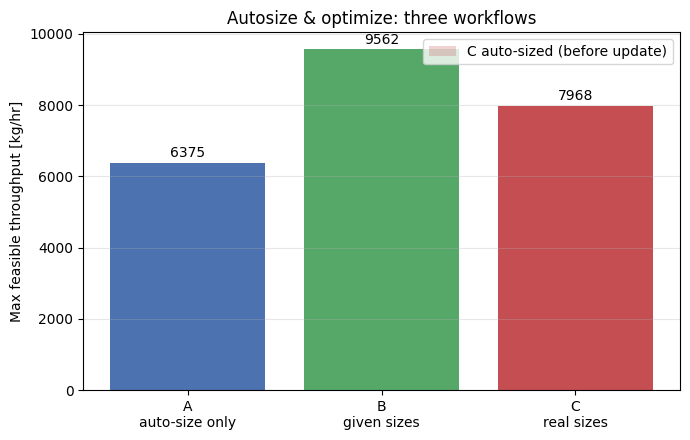

In [7]:
import matplotlib.pyplot as plt

labels = ["A\nauto-size only", "B\ngiven sizes", "C\nreal sizes"]
rates = [optA.getOptimalRate(), optB.getOptimalRate(), optC_real.getOptimalRate()]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, rates, color=["#4C72B0", "#55A868", "#C44E52"])
ax.bar(
    ["C\nreal sizes"],
    [optC_auto.getOptimalRate()],
    color="#C44E52",
    alpha=0.25,
    label="C auto-sized (before update)",
)
for b, r in zip(bars, rates):
    ax.text(
        b.get_x() + b.get_width() / 2,
        r + 80,
        "%.0f" % r,
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylabel("Max feasible throughput [kg/hr]")
ax.set_title("Autosize & optimize: three workflows")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()

figdir = Path("figures")
figdir.mkdir(parents=True, exist_ok=True)
figpath = figdir / "autosize_optimize_scenarios.png"
fig.savefig(figpath, dpi=150, bbox_inches="tight")
print("Saved figure:", figpath)
plt.show()


## Bonus — energy/CO₂ vs production: a Pareto trade-off

The three scenarios above answer *"how much can I produce?"*. Real plants also have to answer
*"how much should I produce?"* — because **more throughput costs more shaft power, and shaft
power costs energy and CO₂**. These two goals genuinely conflict, so the right tool is a
**Pareto** sweep, not a single optimum.

NeqSim already supports this through `ProductionOptimizer.optimizePareto(...)`:

- **Objectives** — maximise export-gas production *and* minimise energy/CO₂ (taken as shaft
  power × an emission factor, here 0.50 kg CO₂/kWh for a gas-turbine driver). Both are
  normalised to O(1) so the weighted-sum scalarisation is balanced.
- **Soft penalty** — keep the compressor ≥ 5 % off surge via an
  `OptimizationConstraint.greaterThan(..., ConstraintSeverity.SOFT, ...)`. Soft constraints
  bend the search rather than rejecting points outright.
- The optimizer sweeps a grid of objective weights, runs the convergence-gated throughput
  search for each, and returns the **non-dominated** operating points.

No new Java is needed — this reuses the same `build_plant()` / `size_for()` helpers.

In [8]:
import jpype

# Multi-objective inner classes (already on ProductionOptimizer).
OptimizationObjective = ProductionOptimizer.OptimizationObjective
ObjectiveType = ProductionOptimizer.ObjectiveType
OptimizationConstraint = ProductionOptimizer.OptimizationConstraint
ConstraintSeverity = ProductionOptimizer.ConstraintSeverity
ArrayList = ns.JClass("java.util.ArrayList")

EF_CO2 = 0.50  # kg CO₂ per kWh of shaft power (gas-turbine driver proxy)
DESIGN = 12000.0  # installed train design throughput [kg/hr]
REF_PROD = DESIGN  # normalisers -> both objectives are O(1) for the weighted sum
REF_PWR = 360.0

# Install a 12 t/hr train, then optimise on it.
pareto_plant = build_plant()
size_for(pareto_plant, DESIGN)
pr_process, pr_feed = pareto_plant["process"], pareto_plant["feed"]


def _export(p):
    return p.getUnit("export cooler").getOutletStream().getFlowRate("kg/hr")


def _power(p):
    return p.getUnit("export compressor").getPower("kW")


def _surge(p):
    return p.getUnit("export compressor").getDistanceToSurge()


def _proxy(fn):
    """Wrap a Python function as a Java ToDoubleFunction<ProcessSystem>."""
    return jpype.JProxy("java.util.function.ToDoubleFunction", dict(applyAsDouble=fn))


# Two conflicting objectives: maximise production, minimise energy/CO₂ (∝ shaft power).
objectives = ArrayList()
objectives.add(
    OptimizationObjective(
        "production", _proxy(lambda p: _export(p) / REF_PROD), 1.0, ObjectiveType.MAXIMIZE
    )
)
objectives.add(
    OptimizationObjective(
        "energy_co2", _proxy(lambda p: _power(p) / REF_PWR), 1.0, ObjectiveType.MINIMIZE
    )
)

# Soft penalty: keep the compressor at least 5 % off surge (never a hard stop).
constraints = ArrayList()
constraints.add(
    OptimizationConstraint.greaterThan(
        "surge_margin",
        _proxy(_surge),
        0.05,
        ConstraintSeverity.SOFT,
        5.0,
        "stay >5% off surge",
    )
)

cfg = (
    OptimizationConfig(0.70 * DESIGN, DESIGN)
    .rateUnit("kg/hr")
    .tolerance(50.0)
    .maxIterations(25)
    .defaultUtilizationLimit(0.95)
    .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
    .paretoGridSize(7)
)

pareto = ProductionOptimizer().optimizePareto(
    pr_process, pr_feed, cfg, objectives, constraints
)
print("Pareto front points:", pareto.getParetoFrontSize())
print(pareto.toMarkdownTable())


Pareto front points: 5
| # | Feasible | production | energy_co2 | Weights |
|---|---|---|---|---|
| 1 | yes | 0.7768 | 0.9207 | [0.83, 0.17] |
| 2 | yes | 0.7768 | 0.9207 | [0.67, 0.33] |
| 3 | yes | 0.7078 | 0.8348 | [0.50, 0.50] |
| 4 | yes | 0.7078 | 0.8348 | [0.17, 0.83] |
| 5 | yes | 0.7078 | 0.8348 | [0.00, 1.00] |



Specific emissions: 0.0177 -> 0.0178 kg CO₂/kg gas (0.3% rise across the window)


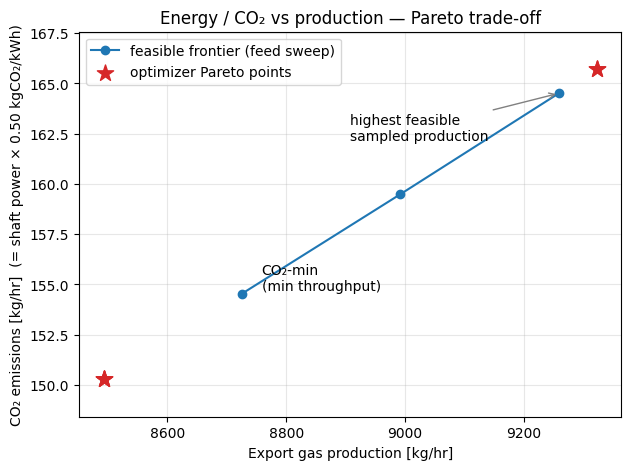

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Continuous feasible frontier: sweep the feed across the operating window.
rates = np.linspace(0.70 * DESIGN, 0.95 * DESIGN, 12)
prod, co2 = [], []
for r in rates:
    pr_feed.setFlowRate(float(r), "kg/hr")
    pr_process.run()
    max_utilization = max(utilization(pr_process).values()) / 100.0
    if max_utilization > 0.95:
        continue
    prod.append(_export(pr_process))
    co2.append(_power(pr_process) * EF_CO2)
prod, co2 = np.array(prod), np.array(co2)

# The optimizer's non-dominated points (re-evaluated in real units).
pf_prod, pf_co2 = [], []
for pt in pareto.getParetoFront():
    feed_rate = list(pt.getDecisionVariables().values())[0]
    pr_feed.setFlowRate(float(feed_rate), "kg/hr")
    pr_process.run()
    assert pt.isFeasible(), "Pareto front contains an infeasible candidate"
    pf_prod.append(_export(pr_process))
    pf_co2.append(_power(pr_process) * EF_CO2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prod, co2, "-o", color="#1f77b4", label="feasible frontier (feed sweep)")
ax.scatter(
    pf_prod,
    pf_co2,
    s=150,
    marker="*",
    color="#d62728",
    zorder=5,
    label="optimizer Pareto points",
)
ax.annotate(
    "CO₂-min\n(min throughput)", (prod[0], co2[0]), textcoords="offset points", xytext=(14, 2)
)
ax.annotate(
    "highest feasible\nsampled production",
    (prod[-1], co2[-1]),
    textcoords="offset points",
    xytext=(-150, -34),
    arrowprops=dict(arrowstyle="->", color="0.5"),
)
ax.set_xlabel("Export gas production [kg/hr]")
ax.set_ylabel("CO₂ emissions [kg/hr]  (= shaft power × %.2f kgCO₂/kWh)" % EF_CO2)
ax.set_title("Energy / CO₂ vs production — Pareto trade-off")
ax.margins(y=0.12)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
figdir = Path("figures")
figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "pareto_energy_co2_vs_production.png", dpi=150, bbox_inches="tight")
plt.show()

intensity = co2 / prod
print(
    "Specific emissions: %.4f -> %.4f kg CO₂/kg gas (%.1f%% rise across the window)"
    % (intensity.min(), intensity.max(), 100.0 * (intensity.max() / intensity.min() - 1.0))
)


**Reading the Pareto front.** On this single-train, fixed-discharge-pressure plant the
trade-off is almost a straight line: CO₂ scales nearly linearly with throughput, so *every*
feasible rate between the CO₂-minimum (lowest throughput) and the production-maximum
(the configured utilization limit) is **non-dominated** — picking an operating point is a business preference,
not a hidden technical optimum. The specific emissions (kg CO₂ / kg gas) still rise modestly
toward the high-flow end, where the compressor runs less efficiently.

The front becomes a genuinely *curved* 2-D Pareto surface as soon as a second knob enters that
trades power against recovery (e.g. export pressure, or a recompression/recycle that recovers
more liquids at the cost of shaft power). The same `optimizePareto(...)` call and soft-penalty
constraints handle that case — just pass a list of `ManipulatedVariable`s instead of the feed
stream. See the
[Production Optimization Guide](https://equinor.github.io/neqsim/examples/PRODUCTION_OPTIMIZATION_GUIDE.html)
for the multi-variable form.

## Scaling to a full plant — multi-area `ProcessModel`

The train above is a single `ProcessSystem`. Real topsides — e.g. an Oseberg / Sture
low-pressure model with many separators, 4–5 compression stages, recompression recycles,
dew-point/TEX and NGL columns — are built as **several `ProcessSystem` areas combined in a
`ProcessModel`**, sharing streams by object reference and converged together.

The *same building blocks* still apply. Only **three things change** for a recycle-heavy,
multi-area plant:

1. **Auto-size works on the whole model.** `ProcessModel.autoSizeEquipment(safety)` sizes every
   unit across all areas in one call — the same method used on a single `ProcessSystem`.
2. **Use the convergence-gated run primitive.** Instead of `process.run()`, drive each trial
   through `automation.evaluate(setpoints, unit, readbacks, …)`, which applies a batch of
   area-qualified setpoints, runs `runUntilConverged` across all areas, and returns one
   `feasible` flag (true only if it converged, no unit failed, and every setpoint was accepted).
   A non-converging or invalid candidate degrades a single trial instead of crashing the loop.
3. **Address variables by area.** Setpoints and read-backs are area-qualified strings —
   `"separation::feed.flowRate"`, `"compression::export compressor.power"` — so an agent never
   navigates the Java object graph.

Below: two areas (`separation` and `compression`) wired by the separator gas stream, auto-sized
as **one** model, then swept for the same energy/CO₂-vs-production trade-off — this time through
the gated multi-area loop.

In [10]:
import json
import numpy as np

ProcessModel = ns.JClass("neqsim.process.processmodel.ProcessModel")
LinkedHashMap = ns.JClass("java.util.LinkedHashMap")
JArrayList = ns.JClass("java.util.ArrayList")

SEP_AREA = "separation"
COMP_AREA = "compression"
PM_DESIGN = 12000.0  # installed design feed [kg/hr]
EF = 0.50  # kg CO₂ per kWh of shaft power (gas-turbine driver proxy)


def build_plant_model(feed_rate_kghr=PM_DESIGN):
    """Two process areas wired by a shared stream reference, composed in a ProcessModel.

    Area 'separation' : feed -> inlet separator (gas / liquid split)
    Area 'compression': export compressor -> export cooler  (fed by the separator gas)
    """
    fluid = SystemSrkEos(273.15 + 45.0, 60.0)
    for c, x in [
        ("methane", 0.80),
        ("ethane", 0.07),
        ("propane", 0.05),
        ("n-butane", 0.03),
        ("n-pentane", 0.02),
        ("water", 0.03),
    ]:
        fluid.addComponent(c, x)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)

    feed = Stream("feed", fluid)
    feed.setFlowRate(feed_rate_kghr, "kg/hr")
    feed.setTemperature(45.0, "C")
    feed.setPressure(60.0, "bara")
    sep = Separator("inlet separator", feed)

    sep_area = ProcessSystem()
    sep_area.add(feed)
    sep_area.add(sep)

    # Cross-area: the compressor is fed by the separator gas stream (owned by area 1).
    comp = Compressor("export compressor", sep.getGasOutStream())
    comp.setOutletPressure(140.0)
    comp.setPolytropicEfficiency(0.78)
    comp.setUsePolytropicCalc(True)
    cooler = Cooler("export cooler", comp.getOutletStream())
    cooler.setOutTemperature(35.0, "C")

    comp_area = ProcessSystem()
    comp_area.add(comp)
    comp_area.add(cooler)

    plant = ProcessModel()
    plant.add(SEP_AREA, sep_area)
    plant.add(COMP_AREA, comp_area)
    return {"plant": plant, "feed": feed, "sep": sep, "comp": comp}


pm = build_plant_model()
plant = pm["plant"]

# 1) Auto-size every unit across BOTH areas with one call (same method as on a ProcessSystem).
plant.runUntilConverged(30, 5.0e-3)
n_sized = plant.autoSizeEquipment(1.2)
plant.runUntilConverged(30, 5.0e-3)

auto = plant.getAutomation()
print("ProcessModel areas :", list(auto.getAreaList()))
print("units auto-sized   :", n_sized)

# 2) Closed-loop sweep through the convergence-GATED automation primitive evaluate().
feed_addr = SEP_AREA + "::feed.flowRate"
prod_addr = SEP_AREA + "::inlet separator.gasOutStream.flowRate"
pwr_addr = COMP_AREA + "::export compressor.power"

rates = np.linspace(0.70 * PM_DESIGN, 0.98 * PM_DESIGN, 15)
pm_prod, pm_co2 = [], []
for r in rates:
    setpoints = LinkedHashMap()
    setpoints.put(feed_addr, float(r))
    # one atomic trial: apply area-qualified setpoint -> runUntilConverged -> gate feasibility
    res = json.loads(str(auto.evaluate(setpoints, "kg/hr", JArrayList(), "kg/hr", 30, 5.0e-3)))
    snapshot = json.loads(str(plant.getUtilizationSnapshotJson()))
    max_utilization = max(unit.get("maxUtilizationPercent", 0.0) for unit in snapshot["units"])
    if not res["feasible"] or snapshot["anyOverloaded"] or max_utilization > 95.0:
        print("  feed %7.0f kg/hr -> infeasible (skipped)" % r)
        continue
    pm_prod.append(auto.getVariableValue(prod_addr, "kg/hr"))
    pm_co2.append(auto.getVariableValue(pwr_addr, "kW") * EF)

pm_prod, pm_co2 = np.array(pm_prod), np.array(pm_co2)
assert len(pm_prod) > 1, "At least two capacity-feasible trials are required"
print("feasible trials    :", len(pm_prod))
print("production range   : %.0f - %.0f kg/hr" % (pm_prod.min(), pm_prod.max()))
print("CO₂ range          : %.0f - %.0f kg/hr" % (pm_co2.min(), pm_co2.max()))


ProcessModel areas : ['separation', 'compression']
units auto-sized   : 3
  feed    8400 kg/hr -> infeasible (skipped)
  feed    8640 kg/hr -> infeasible (skipped)
  feed    9600 kg/hr -> infeasible (skipped)
  feed    9840 kg/hr -> infeasible (skipped)
  feed   10080 kg/hr -> infeasible (skipped)
  feed   10320 kg/hr -> infeasible (skipped)
  feed   10560 kg/hr -> infeasible (skipped)
  feed   10800 kg/hr -> infeasible (skipped)
  feed   11040 kg/hr -> infeasible (skipped)
  feed   11280 kg/hr -> infeasible (skipped)
  feed   11520 kg/hr -> infeasible (skipped)
  feed   11760 kg/hr -> infeasible (skipped)
feasible trials    : 3
production range   : 8662 - 9131 kg/hr
CO₂ range          : 153 - 162 kg/hr


Specific emissions: 0.0177 -> 0.0178 kg CO₂/kg gas across the feasible window (0.3% rise)


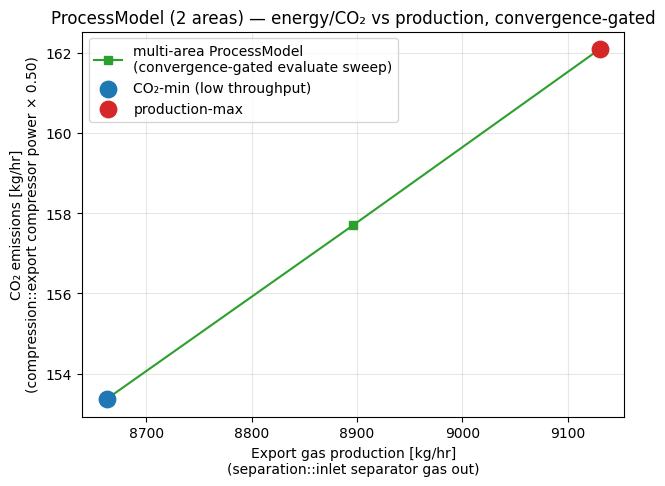

In [11]:
import matplotlib.pyplot as plt
from pathlib import Path

order = np.argsort(pm_prod)
xp, yp = pm_prod[order], pm_co2[order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    xp,
    yp,
    "-s",
    color="#2ca02c",
    label="multi-area ProcessModel\n(convergence-gated evaluate sweep)",
)
ax.scatter(
    [xp[0]], [yp[0]], s=140, color="#1f77b4", zorder=5, label="CO₂-min (low throughput)"
)
ax.scatter([xp[-1]], [yp[-1]], s=140, color="#d62728", zorder=5, label="production-max")
ax.set_xlabel("Export gas production [kg/hr]\n(separation::inlet separator gas out)")
ax.set_ylabel("CO₂ emissions [kg/hr]\n(compression::export compressor power × %.2f)" % EF)
ax.set_title("ProcessModel (2 areas) — energy/CO₂ vs production, convergence-gated")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
figdir = Path("figures")
figdir.mkdir(parents=True, exist_ok=True)
fig.savefig(figdir / "pareto_processmodel_multiarea.png", dpi=150, bbox_inches="tight")
plt.show()

pm_intensity = yp / xp
print(
    "Specific emissions: %.4f -> %.4f kg CO₂/kg gas across the feasible window (%.1f%% rise)"
    % (
        pm_intensity.min(),
        pm_intensity.max(),
        100.0 * (pm_intensity.max() / pm_intensity.min() - 1.0),
    )
)


**Same trade-off, now across two coupled areas.** Every point on the green frontier is a
*fully converged* multi-area solution: `evaluate()` ran both areas with `runUntilConverged`
and only kept trials where `feasible == True` and the capacity snapshot
confirmed at most 95% utilization. Convergence alone does not certify capacity. Production is read from
`separation::inlet separator.gasOutStream` and the energy/CO₂ from
`compression::export compressor.power` — across the area boundary, **by name**, with no Java
navigation.

For a real topside like the Oseberg / Sture low-pressure model this scales directly:

- the **decision vector grows** (separator stage pressures, recompression split, export-compressor
  discharge, heater outlet temperatures) — just add more entries to the `setpoints` map;
- the **constraints become real specs** — export-oil **RVP** via `Standard_ASTM_D6377` and
  per-compressor **surge margin** via `Compressor.getOperatingPoint` — read them back and
  gate / penalise on them;
- `automation.getAdjustableParameters()` enumerates the bounded, writable decision space
  automatically, so an agent never has to hard-code addresses.

This is exactly the convergence-gated, closed-loop pattern documented in the
**`neqsim-agentic-process-optimization`** skill and the **`@optimize.plant`** agent for
optimizing large multi-area `ProcessModel` plants.

## Takeaways

- **Minimal Python.** One `build_plant()` builder, a handful of helpers, and a single
  `maximize_throughput()` call drive every scenario. All sizing, constraint building and the
  throughput search happen inside Java NeqSim.
- **Works with little input.** Scenario A starts from nothing but stream conditions —
  `autoSizeEquipment()` makes the plant optimizable in one call.
- **Easy to modify sizes.** Supplying real equipment data is a one-line change
  (`size_for(...)` for the design duty, or `setDesignGasLoadFactor` for an explicit
  separator size), and the optimizer immediately reflects the new binding constraint.
- **Full life-cycle.** Scenario C shows the common pattern: auto-size for an early estimate,
  then update with the larger preliminary design basis and re-optimize using the *same* code.

See the [Production Optimization Guide](https://equinor.github.io/neqsim/examples/PRODUCTION_OPTIMIZATION_GUIDE.html)
for the full optimizer API (custom objectives, multiple decision variables, utilization limits).